# EURO-CORDEX

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy
import rasterio
import xarray
import affine
import numpy as np
import torch
import pathlib
import matplotlib
from pyproj import Transformer

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

import models
import loss
import datasets

Open an example

<xarray.DataArray 'time' ()> Size: 8B
array('2012-12-31T12:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    rotated_latitude_longitude  int32 4B -2147483647
    height                      float64 8B 2.0


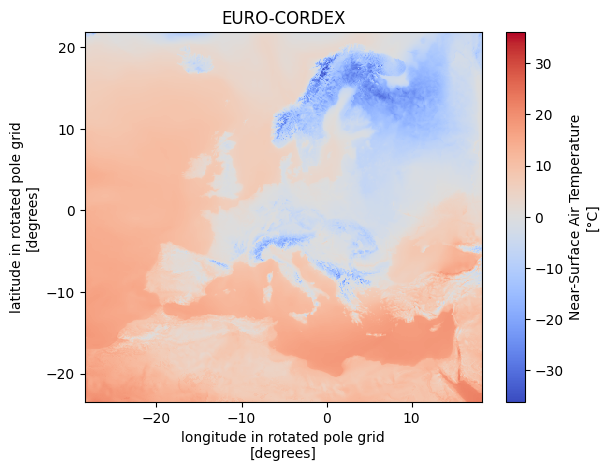

In [2]:
cordex = xarray.open_mfdataset('/home/tomas/ctu/current/rci_data/climate/CORDEX/tas/tas_EUR-11_ECMWF-ERAINT_evaluation_r1i1p1_GERICS-REMO2015_v1_day_*.nc', decode_coords="all")
cordex = cordex["tas"]

DATE = '2005-12-18'

cordex = cordex.sel(time=DATE)
cordex -= 273.15

cordex.attrs['units'] = '°C'

fig, ax = plt.subplots(ncols=1, rasterized=True)
cordex.plot(ax = ax, cmap="coolwarm")
ax.set_title('EURO-CORDEX')
plt.show()
fig.savefig('images/cordex.pdf', bbox_inches='tight', dpi=300)

Unrotated pole

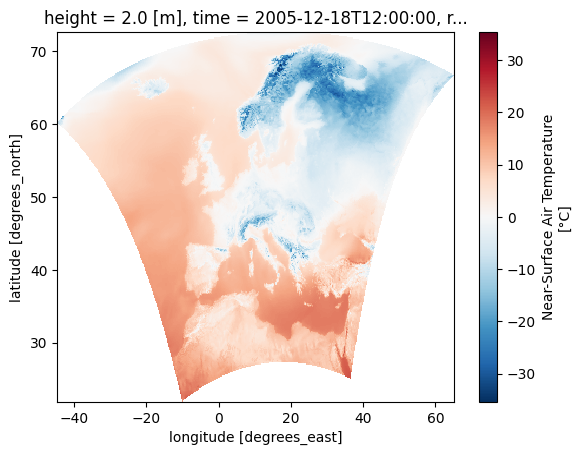

In [3]:
tas_latlon = cordex.rio.reproject("EPSG:4326")
tas_latlon = tas_latlon.rio.write_crs("EPSG:4326")

tas_latlon.plot()

3-degree Gauss-Kruger zone 4 EPSG projection -> same as ReKIS

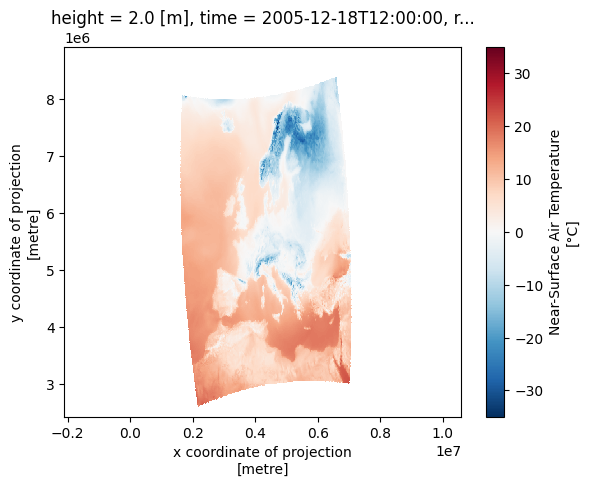

In [4]:
cordex_reprojected = tas_latlon.rio.reproject("EPSG:31468",
    resampling=rasterio.enums.Resampling.average
)
cordex_reprojected.plot()

Load ReKIS and obtain bounds in the EPSG:31468

In [5]:
CLIMATE_VARIABLE = 'TM'
FILE_PATH = f'/home/tomas/ctu/current/rci_data/climate/ReKIS/KlimRefDS_v3.1_1961-2023/Raster/Tag/GK4/{CLIMATE_VARIABLE}/{CLIMATE_VARIABLE}_*.nc'

x = xr.open_mfdataset(FILE_PATH, decode_coords="all")
x = x[CLIMATE_VARIABLE]
x = x.rio.set_spatial_dims(x_dim="easting", y_dim="northing")
x = x.rio.write_crs("EPSG:31468")
x = x.isel(easting=slice(0, 400), northing=slice(0, 400))
x = x.rio.set_spatial_dims(x_dim="easting", y_dim="northing")
x = x.sel(time=DATE)
x = x.rio.set_spatial_dims(x_dim="easting", y_dim="northing")
bounds = x.rio.bounds()
print(bounds)

(4335000.0, 5555000.0, 4735000.0, 5955000.0)


Visualize native EURO-CORDEX on the area of ReKIS

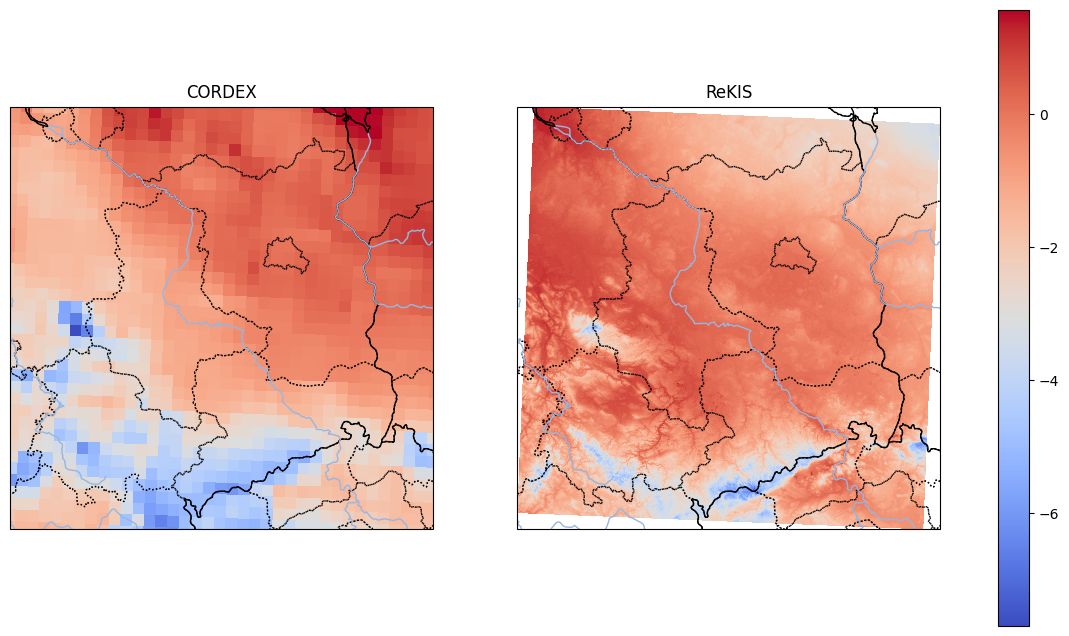

In [6]:
fig, axs = plt.subplots(ncols=2, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (15, 8))


cordex_reprojected_vals = cordex_reprojected.sel(y = slice( bounds[3], bounds[1]),
                                               x = slice(bounds[0], bounds[2]))

vmin = min(cordex_reprojected_vals.min().values, x.min().values)
vmax = max(cordex_reprojected_vals.max().values, x.max().values)

norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

im = cordex_reprojected.plot(
    ax=axs[0],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[0].set_extent(
    [bounds[0], bounds[2], bounds[1], bounds[3]],  # left, right, bottom, top
    crs=cartopy.crs.epsg(31468)
)

axs[0].set_title('CORDEX')

x.plot(
    ax=axs[1],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[1].set_title('ReKIS')

fig.colorbar(im, ax = axs)

for ax in axs:
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.STATES, linestyle=":")
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.COASTLINE)
plt.show()

Modify both to obtain the same resolution in the matching area with same EPSG.

In [7]:
cordex_example = cordex.rio.reproject(
        dst_crs="EPSG:31468",
        transform=affine.Affine(16000.0, 0.0, 4335000.0, 0.0, -16000.0, 5955000.0),
        shape=(400 // 16, 400 // 16),
        resampling=rasterio.enums.Resampling.average
)

rekis_upscaled = x.rio.reproject(
        dst_crs="EPSG:31468",
        resolution=(16_000, 16_000),
        resampling=rasterio.enums.Resampling.average
)

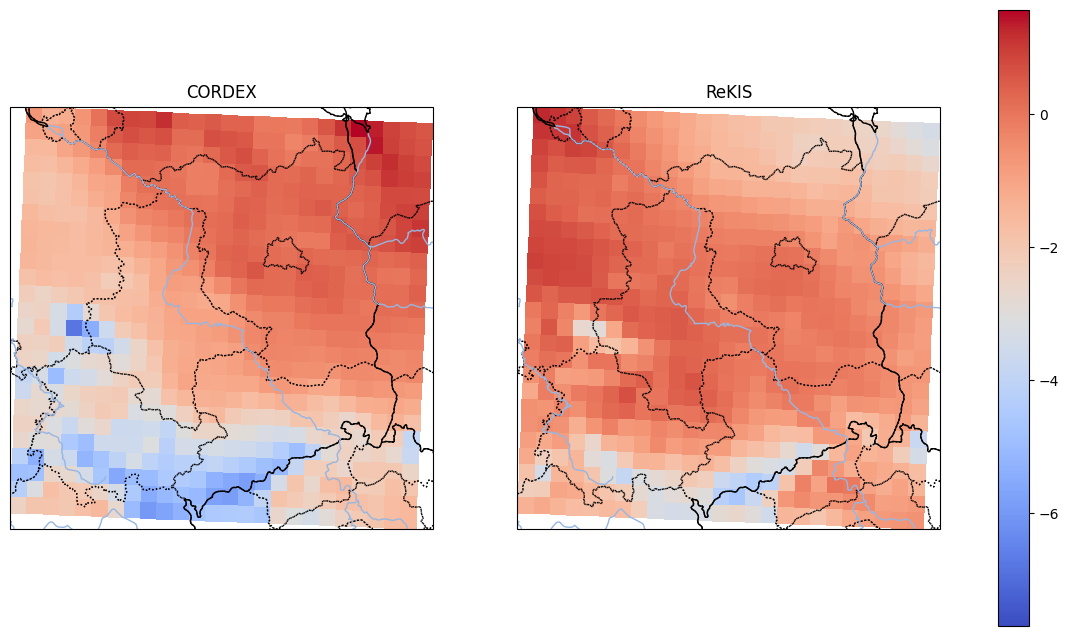

In [8]:
fig, axs = plt.subplots(ncols=2, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (15, 8))

norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

im = cordex_example.plot(
    ax=axs[0],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[0].set_title('CORDEX')

rekis_upscaled.plot(
    ax=axs[1],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[1].set_title('ReKIS')

fig.colorbar(im, ax = axs)

for ax in axs:
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.STATES, linestyle=":")
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.COASTLINE)
plt.show()

In [9]:
SCALE_FACTOR = 16

CKPT_DIR = '/home/tomas/ctu/current/rci_home/SISR-downscaling/logs/lightning_logs/'
def load_checkpoint(version: int):
    dir = pathlib.Path(CKPT_DIR + f'version_{version}/checkpoints/')
    return [file for file in dir.iterdir() if file.is_file() and file.suffix == '.ckpt'][0]

torch.set_float32_matmul_precision("high")
ckpt = load_checkpoint(455)

model = models.ConstrainedModel.load_from_checkpoint(checkpoint_path = ckpt,
                                                     model=models.EDSR(channels=1, scale_factor=SCALE_FACTOR, features=128, residual_blocks=64, loss=loss.LossCombination([1], [loss.L1Loss()])),
                                                     constraint=models.AddConstraintLayer(SCALE_FACTOR)).cuda()
model.eval()

/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'constraint' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['constraint'])`.


ConstrainedModel(
  (train_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=train/
  )
  (val_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=val/
  )
  (test_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=test/
  )
  (model): EDSR(
    (train_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=train/
    )
    (val_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=val/
    )
    (test_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=test/
    )
    (loss): LossCombination(


In [10]:
input = torch.from_numpy(cordex_example.values).reshape(1, 1, 25, 25).cuda()

In [11]:
cordex_downscaled = model(input).cpu().detach().squeeze().numpy()

In [12]:
left, bottom, right, top = 4335000, 5555000, 4755000, 5955000

easting  = np.linspace(left, right, 400)
northing = np.linspace(top, bottom, 400)

cordex_downscaled = xr.DataArray(
    cordex_downscaled,
    dims=["northing", "easting"],
    coords={
        "northing": northing,
        "easting":  easting,
    }
)
cordex_downscaled = cordex_downscaled.rio.write_crs("EPSG:31468")
cordex_downscaled = cordex_downscaled.rio.set_spatial_dims(x_dim="easting", y_dim="northing")

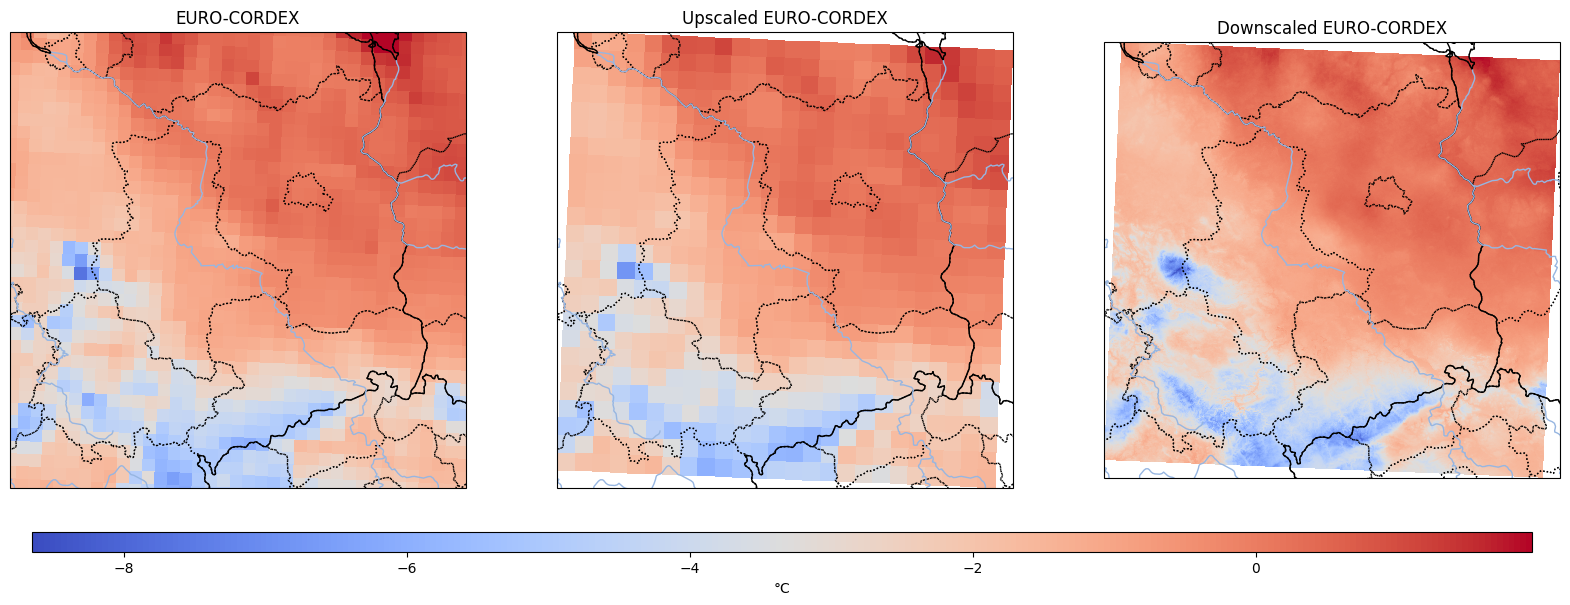

In [13]:
fig, axs = plt.subplots(ncols=3, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (20, 8), rasterized=True)

vmin = min(cordex_example.min().values, cordex_reprojected_vals.min().values, cordex_downscaled.min().values)
vmax = max(cordex_example.max().values, cordex_reprojected_vals.max().values, cordex_downscaled.max().values)

norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

im = cordex_reprojected.plot(
    ax=axs[0],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)


axs[0].set_extent(
    [bounds[0], bounds[2], bounds[1], bounds[3]],  # left, right, bottom, top
    crs=cartopy.crs.epsg(31468)
)
axs[0].set_title('EURO-CORDEX')

cordex_example.plot(
    ax=axs[1],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[1].set_title('Upscaled EURO-CORDEX')

cordex_downscaled.plot(
    ax=axs[2],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[2].set_title('Downscaled EURO-CORDEX')


fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.136, 0.15, 0.75, 0.025])
fig.colorbar(im, cax = cbar_ax, orientation='horizontal', label='°C')

for i in range(3):
    ax = axs[i]
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.STATES, linestyle=":")
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.COASTLINE)

fig.savefig('downscaled_cordex.pdf', bbox_inches='tight', dpi=300)

plt.show()

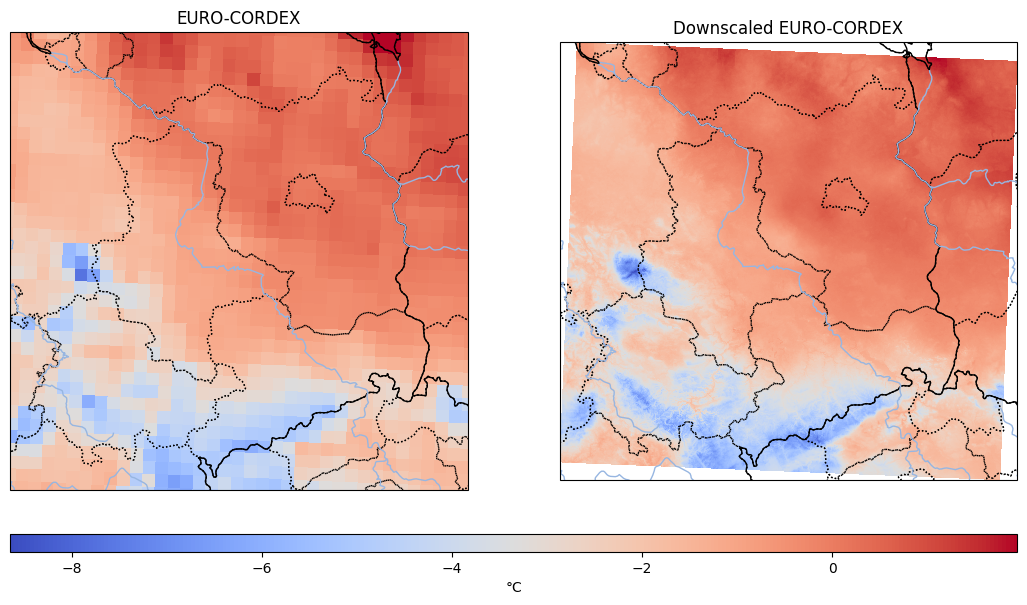

In [14]:
fig, axs = plt.subplots(ncols=2, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (13, 7), rasterized=True)

vmin = min(cordex_reprojected_vals.min().values, cordex_downscaled.min().values)
vmax = max(cordex_reprojected_vals.max().values, cordex_downscaled.max().values)

norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

im = cordex_reprojected.plot(
    ax=axs[0],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)


axs[0].set_extent(
    [bounds[0], bounds[2], bounds[1], bounds[3]],  # left, right, bottom, top
    crs=cartopy.crs.epsg(31468)
)
axs[0].set_title('EURO-CORDEX')

cordex_downscaled.plot(
    ax=axs[1],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[1].set_title('Downscaled EURO-CORDEX')


fig.subplots_adjust(bottom=0.15)

left = axs[0].get_position().x0
width = axs[1].get_position().x1 - left

cbar_ax = fig.add_axes([left, 0.1, width, 0.025])
fig.colorbar(im, cax = cbar_ax, orientation='horizontal', label='°C')

for i in range(2):
    ax = axs[i]
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.STATES, linestyle=":")
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.COASTLINE)

fig.savefig('images/downscaled_cordex.pdf', bbox_inches='tight', dpi=300)

plt.show()

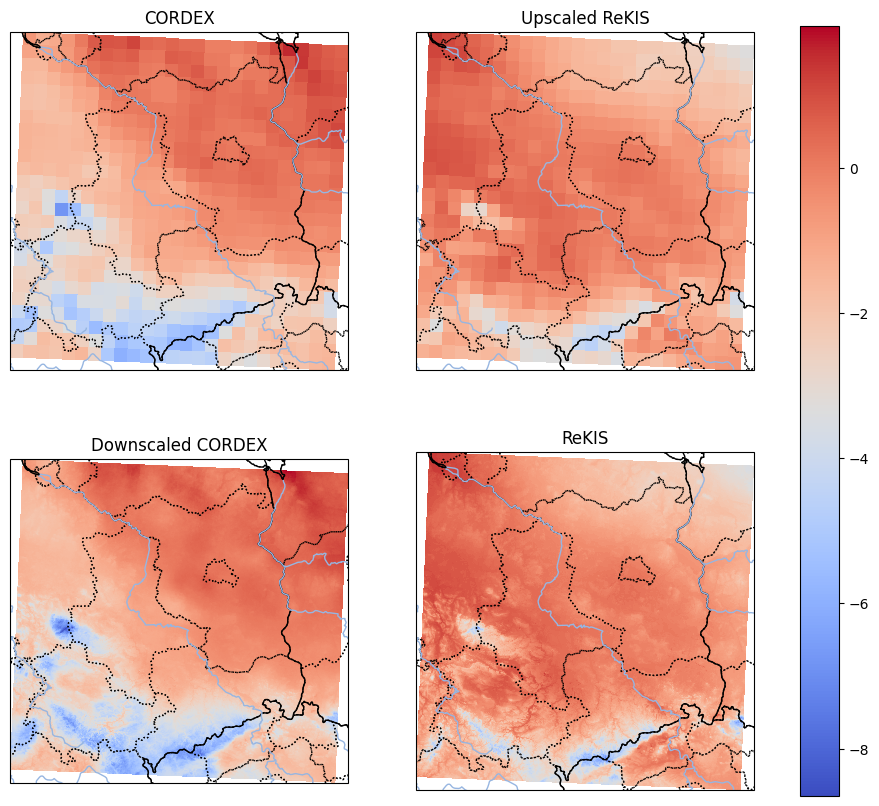

In [15]:
fig, axs = plt.subplots(ncols=2, nrows=2, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (12, 10))

vmin = min(cordex_example.min().values, cordex_downscaled.min().values, x.min().values, rekis_upscaled.min().values)
vmax = max(cordex_example.max().values, cordex_downscaled.max().values, x.max().values, rekis_upscaled.max().values)

norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

im = cordex_example.plot(
    ax=axs[0, 0],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[0, 0].set_title('CORDEX')

rekis_upscaled.plot(
    ax=axs[0, 1],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[0, 1].set_title('Upscaled ReKIS')

cordex_downscaled.plot(
    ax=axs[1, 0],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[1, 0].set_title('Downscaled CORDEX')

x.plot(
    ax=axs[1, 1],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[1, 1].set_title('ReKIS')

fig.colorbar(im, ax = axs)

for i in range(2):
    for j in range(2):
        ax = axs[i, j]
        ax.add_feature(cartopy.feature.BORDERS)
        ax.add_feature(cartopy.feature.STATES, linestyle=":")
        ax.add_feature(cartopy.feature.RIVERS)
        ax.add_feature(cartopy.feature.COASTLINE)
plt.show()

In [16]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:31468", always_xy=True)

berlin_east, berlin_north = transformer.transform(13.41, 52.52)
prague_east,  prague_north  = transformer.transform(14.42, 50.08)
region = 25_000

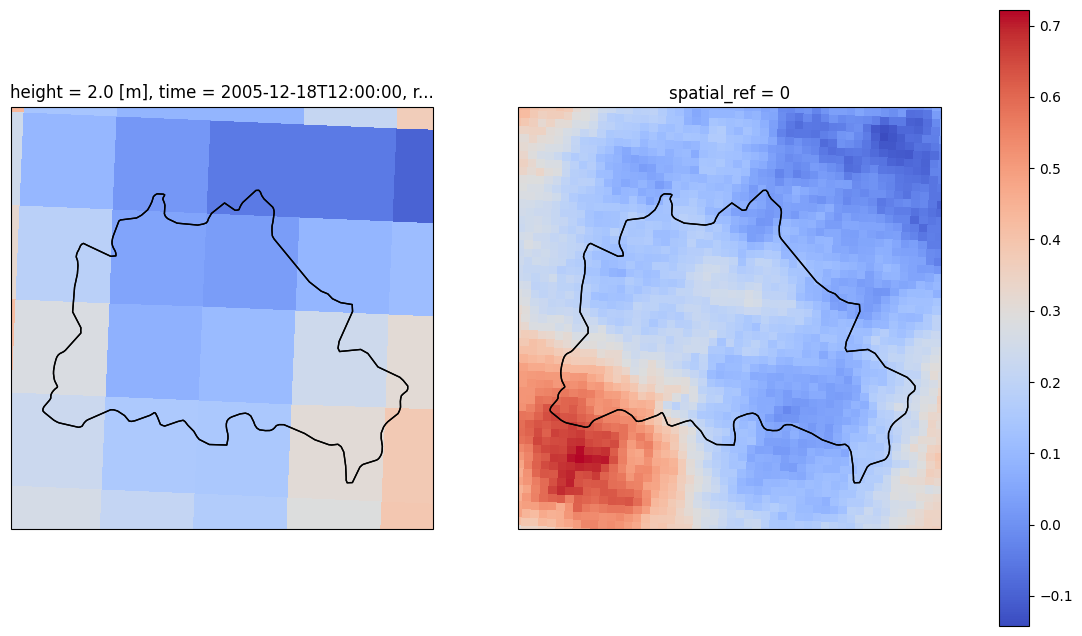

In [17]:
fig, axs = plt.subplots(ncols=2, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (15, 8))

berlin_downscaled_vals = cordex_downscaled.sel(northing = slice(berlin_north + region, berlin_north - region),
                                               easting = slice(berlin_east - region, berlin_east + region))

berlin_reprojected_vals = cordex_reprojected.sel(y = slice( berlin_north + region, berlin_north - region),
                                               x = slice(berlin_east - region, berlin_east + region))

vmin = min(berlin_reprojected_vals.min().values, berlin_downscaled_vals.min().values)
vmax = max(berlin_reprojected_vals.max().values, berlin_downscaled_vals.max().values)

norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

im = cordex_reprojected.plot(
    ax=axs[0],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

cordex_downscaled.plot(
    ax=axs[1],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

for ax in axs:
    ax.set_extent(
        [berlin_east - region, berlin_east + region, berlin_north + region, berlin_north - region],  # left, right, bottom, top
        crs=cartopy.crs.epsg(31468)
    )

fig.colorbar(im, ax = axs)

for ax in axs:
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.STATES)
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.COASTLINE)
plt.show()

ValueError: zero-size array to reduction operation fmin which has no identity

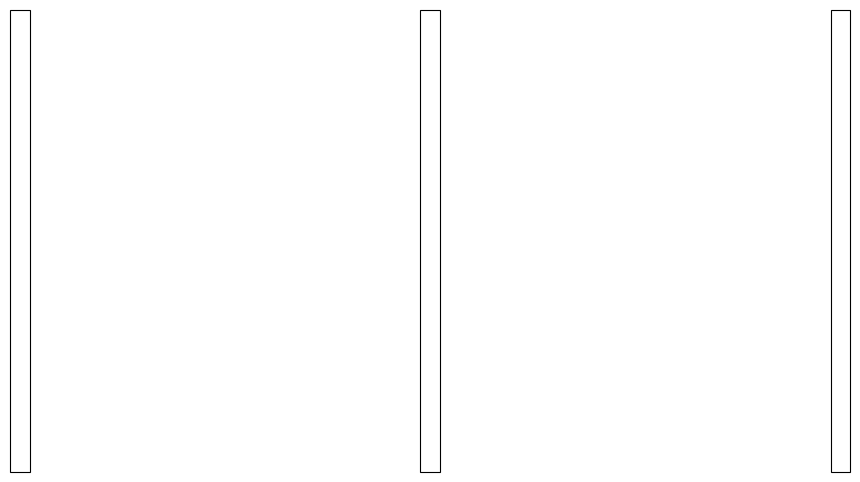

In [19]:
fig, axs = plt.subplots(ncols=3, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (15, 6))

prague_reprojected_vals = cordex_reprojected.sel(y = slice( prague_north + region, prague_north - region),
                                               x = slice(prague_east - region, prague_east + region))

vmin = min(prague_reprojected_vals.min().values, vmin)
vmax = max(prague_reprojected_vals.max().values, vmax)

norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

im = cordex_reprojected.plot(
    ax=axs[0],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[0].set_title('EURO-CORDEX Berlin')

cordex_downscaled.plot(
    ax=axs[1],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[1].set_title('downscaled EURO-CORDEX Berlin')



cordex_reprojected.plot(
    ax=axs[2],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[2].set_title('EURO-CORDEX Prague')


for i in range(2):
    axs[i].set_extent(
        [berlin_east - region, berlin_east + region, berlin_north + region, berlin_north - region],  # left, right, bottom, top
        crs=cartopy.crs.epsg(31468)
    )

axs[2].set_extent(
    [prague_east - region, prague_east + region, prague_north + region, prague_north - region],  # left, right, bottom, top
    crs=cartopy.crs.epsg(31468)
)

fig.colorbar(im, ax = axs)

for ax in axs:
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.STATES)
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.COASTLINE)

    scalebar = AnchoredSizeBar(
        ax.transData,
        10_000,
        f"{10} km",
        loc="lower right",
        pad=0.5,
        color="black",
        frameon=True,
        size_vertical=250,
        fontproperties=fm.FontProperties(size=10)
    )

    ax.add_artist(scalebar)

plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=2, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (15, 8))

berlin_downscaled_vals = cordex_downscaled.sel(northing = slice(berlin_north + region, berlin_north - region),
                                               easting = slice(berlin_east - region, berlin_east + region))

berlin_reprojected_vals = cordex_reprojected.sel(y = slice( berlin_north + region, berlin_north - region),
                                               x = slice(berlin_east - region, berlin_east + region))

vmin = min(berlin_reprojected_vals.min().values, berlin_downscaled_vals.min().values)
vmax = max(berlin_reprojected_vals.max().values, berlin_downscaled_vals.max().values)

norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

im = cordex_reprojected.plot(
    ax=axs[0],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

cordex_downscaled.plot(
    ax=axs[1],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

for ax in axs:
    ax.set_extent(
        [berlin_east - region, berlin_east + region, berlin_north + region, berlin_north - region],  # left, right, bottom, top
        crs=cartopy.crs.epsg(31468)
    )

fig.colorbar(im, ax = axs)

for ax in axs:
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.STATES)
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.COASTLINE)

    scalebar = AnchoredSizeBar(
        ax.transData,
        10_000,
        f"{10} km",
        loc="lower right",
        pad=0.5,
        color="black",
        frameon=True,
        size_vertical=500,
        fontproperties=fm.FontProperties(size=10)
    )

    ax.add_artist(scalebar)

plt.show()

In [ ]:
fig, ax = plt.subplots(ncols=1, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (20, 12))

berlin_downscaled_vals = cordex_downscaled.sel(northing = slice(berlin_north + region, berlin_north - region),
                                               easting = slice(berlin_east - region, berlin_east + region))

berlin_reprojected_vals = cordex_reprojected.sel(y = slice( berlin_north + region, berlin_north - region),
                                               x = slice(berlin_east - region, berlin_east + region))

vmin = berlin_downscaled_vals.min().values
vmax = berlin_downscaled_vals.max().values

norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

im=cordex_downscaled.plot(
    ax=ax,
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

ax.set_extent(
    [berlin_east - region, berlin_east + region, berlin_north + region, berlin_north - region],  # left, right, bottom, top
    crs=cartopy.crs.epsg(31468)
)

fig.colorbar(im, ax = ax)

ax.add_feature(cartopy.feature.BORDERS)
ax.add_feature(cartopy.feature.STATES)
ax.add_feature(cartopy.feature.RIVERS)
ax.add_feature(cartopy.feature.COASTLINE)

scalebar = AnchoredSizeBar(
    ax.transData,
    10_000,
    f"{10} km",
    loc="lower right",
    pad=0.5,
    color="black",
    frameon=True,
    size_vertical=500,
    fontproperties=fm.FontProperties(size=10)
)

ax.add_artist(scalebar)

plt.show()